In [60]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def theoretical_curves(T):
        b = 1/T
        J = 1.0
        h = 0.02
        Ns = 50
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        U = -J*(th + ch*thN)/(1 + thN)
        heat=((b*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
        l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        Z = l1**Ns + l2**Ns
        M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
                + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
        X = b*np.exp(2*b*J)*(1-thN)/(1+thN)

        return [U, heat, X, M]

### Metropolis and Gibbs Simulation of the Ising 1D model

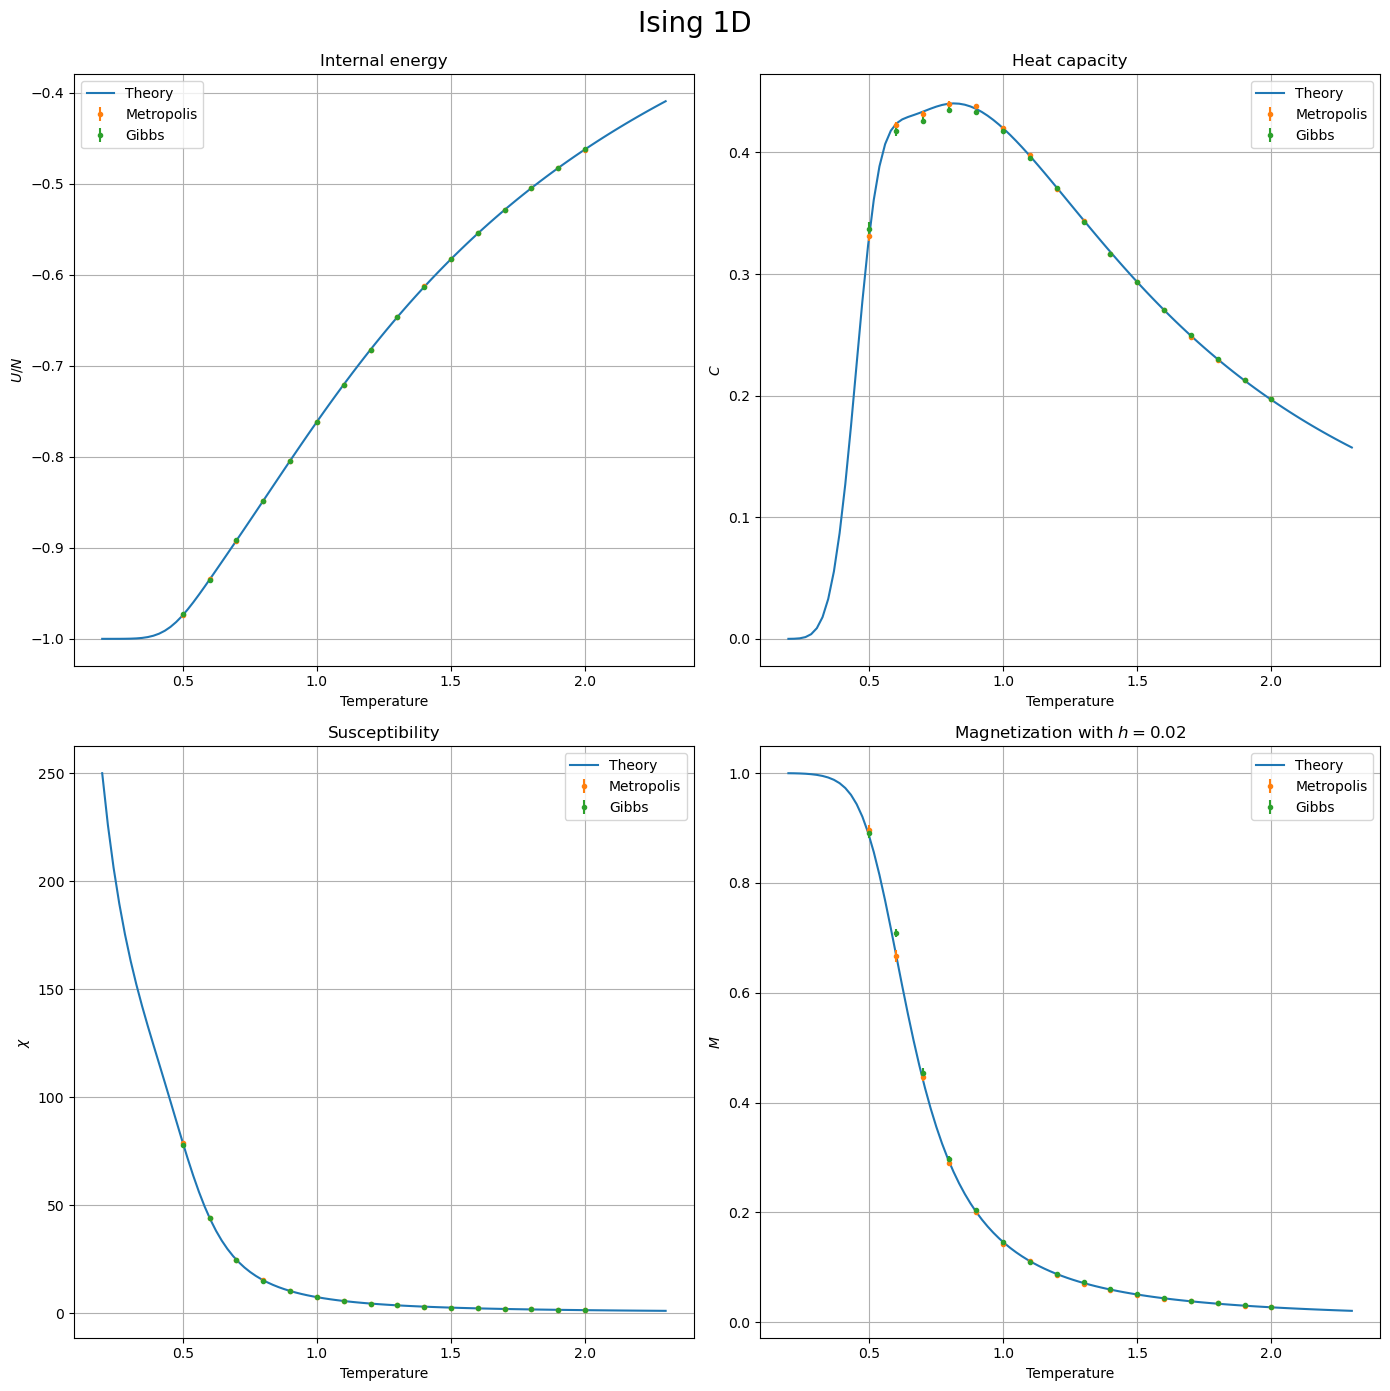

In [ ]:
x = np.arange(16)
T_teo = np.linspace(0.2,2.3,100)
T_exp = np.arange(0.5,2.1,0.1)

u_metr = np.array([np.loadtxt(f"../OUTPUT/METRO/total_energy_{15-i}.dat", usecols=(2,3))[-1] for i in x])
u_gibbs = np.array([np.loadtxt(f"../OUTPUT/GIBBS/total_energy_{15-i}.dat", usecols=(2,3))[-1] for i in x])

cv_metr = np.array([np.loadtxt(f"../OUTPUT/METRO/specific_heat_{15-i}.dat", usecols=(2,3))[-1] for i in x])
cv_gibbs = np.array([np.loadtxt(f"../OUTPUT/GIBBS/specific_heat_{15-i}.dat", usecols=(2,3))[-1] for i in x])

chi_metr = np.array([np.loadtxt(f"../OUTPUT/METRO/susceptibility_{15-i}.dat", usecols=(2,3))[-1] for i in x])
chi_gibbs = np.array([np.loadtxt(f"../OUTPUT/GIBBS/susceptibility_{15-i}.dat", usecols=(2,3))[-1] for i in x])

magnet_metr = np.array([np.loadtxt(f"../OUTPUT/METRO/magnetization_{15-i}.dat", usecols=(2,3))[-1] for i in x])
magnet_gibbs = np.array([np.loadtxt(f"../OUTPUT/GIBBS/magnetization_{15-i}.dat", usecols=(2,3))[-1] for i in x])

fig, ax = plt.subplots(2, 2, figsize=(14,14))
ax = ax.flatten()

theory = theoretical_curves(T)
metropolis = [u_metr, cv_metr, chi_metr, magnet_metr]
gibbs = [u_gibbs, cv_gibbs, chi_gibbs, magnet_gibbs]
ylabels = ["$U/N$", "$C$", "$\\chi$", "$M$"]
titles = ["Internal energy", "Heat capacity", "Susceptibility", "Magnetization with $h = 0.02$"]

for i in range(4):
    ax[i].plot(T_teo, theory[i], label="Theory")
    ax[i].errorbar(T_exp, metropolis[i][:,0], yerr=metropolis[i][:,1], fmt=".", label="Metropolis")
    ax[i].errorbar(T_exp, gibbs[i][:,0], yerr=gibbs[i][:,1], fmt=".", label="Gibbs")
    ax[i].set_title(titles[i])
    ax[i].set_xlabel('Temperature')
    ax[i].set_ylabel(ylabels[i])
    ax[i].grid()
    ax[i].legend()

fig.suptitle('Ising 1D', fontsize=20, y=0.99)
plt.tight_layout()
plt.show()

### Commenti
Per ciascun metodo di campionamento (sia Metrolopis che Gibbs) sono state condotte 16 simulazioni corrispondenti a 16 temperature diverse che variavano nell'intervallo $[0.5, 2.0]$. Inoltre, è stato svolto prima il caso con campo esterno $h = 0$ e poi il caso con campo esterno non nullo per campionare l'andamento della magnetizzazione. Per i valori ad alta temperatura sono stati usati 20 blocchi da 20000 steps, mentre a temperature basse (intervallo $[0.5, 1.2]$) sono stati utilizzati 40000 steps per avere risultati più precisi. Tutto ciò è stato svolto tramite uno script.

Come si può notare dai grafici, i valori sperimentali seguono abbastanza fedelmente l'andamento teorico salvo qualche eccezione. Risultati ancora più precisi si sarebbero potuti ottenere svolgendo un'equilibrazione prima di ogni simulazione.
